# Part 3: Prompting Strategies for Vision-Language Models

## Lesson Overview

We will explore how different prompting strategies affect model behavior when working with images.

The task stays the same throughout:

**Given an image, classify it as:**

* `Class: UT Austin`
* `Class: UT San Antonio`


## Important Output Rule (Applies to ALL Strategies)

Your prompt must follow this rule:

* The **last line only** must be:

  * `Class: UT Austin` OR
  * `Class: UT San Antonio`

The model **may reason or describe earlier**, but:

* The final line must follow the exact format
* Do not include extra text after the final line
* Do not include punctuation after the label
* Do not include multiple final answers


# Strategy 1: Zero-Shot Prompting

## What is Zero-Shot?

You give **no examples**, only instructions.


## Example




In [4]:
from utils import preprocess_image_to_data_url
from IPython.display import display, Markdown
from PIL import Image
import matplotlib.pyplot as plt

from openai import OpenAI

key = "gpustack_d230867d00abae37_390e4dac2dd24f61c4e2f6971c403883"
client = OpenAI(base_url="http://10.246.100.230/v1", api_key=key)

# Image paths
image_paths = [
    "./datasets/birds-vs-horns/horns-1.jpeg",
    "./datasets/birds-vs-horns/birds-up-2.jpeg",
    "./datasets/birds-vs-horns/horns-2.jpg",
    "./datasets/birds-vs-horns/birds-up-1.jpg",
]

# Titles shown to students
titles = [
    "Image 1",
    "Image 2",
    "Image 3",
    "Image 4",
]

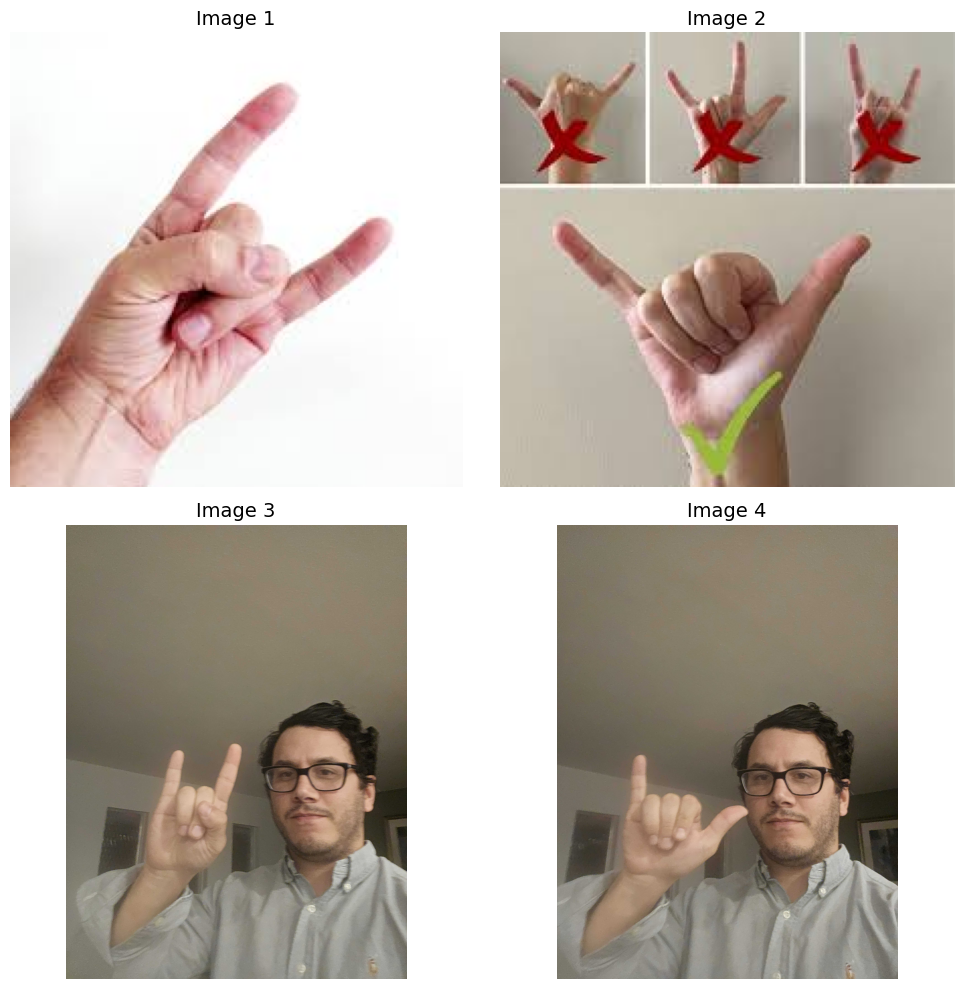

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, path, title in zip(axes, image_paths, titles):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(title, fontsize=14)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:

# =========================
# STUDENT SECTION (EDIT THIS ONLY)
# =========================
prompt = """
Look at the image and determine whether the hand gesture corresponds to UT Austin or UT San Antonio.

You may briefly think about the gesture before answering.

The final line must be exactly one of:
Class: UT Austin
Class: UT San Antonio
"""

# =========================
# RUN MODEL (DO NOT MODIFY)
# =========================
for i, path in enumerate(image_paths):
    img_url = preprocess_image_to_data_url(path)

    resp = client.chat.completions.create(
        model="qwen3-vl-32b-instruct",
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {"type": "image_url", "image_url": {"url": img_url}},
                ],
            }
        ],
        temperature=0.2,
        max_tokens=1000,
    )

    print(f"Image {i+1} Prediction:")
    print(resp.choices[0].message.content.strip())
    print("-" * 40)


Image 1 Prediction:
The hand gesture shown is the "hook 'em horns" sign, which is famously associated with the University of Texas at Austin (UT Austin). This gesture is made by extending the index and pinky fingers while curling the middle and ring fingers down, and it is a well-known symbol of UT Austin's mascot, Bevo, and school spirit.

UT San Antonio does not use this gesture as part of its official traditions or symbols.

Class: UT Austin
----------------------------------------
Image 2 Prediction:
The hand gesture shown in the bottom image is the "hook 'em horns" gesture, which is the iconic hand sign associated with the University of Texas at Austin (UT Austin). The top three images show incorrect gestures with red X's, while the bottom one shows the correct gesture with a green checkmark.

This gesture is famously used by UT Austin fans and is deeply tied to their school spirit.

Class: UT Austin
----------------------------------------
Image 3 Prediction:
The hand gesture sho

## Key Idea

* Simple and direct
* May be inconsistent without examples

# Strategy 2: Few-Shot Prompting

## What is Few-Shot?

You give **example images + correct answers** before the real input.

## Example

In [9]:
image_paths_ex = [
    "./datasets/birds-vs-horns/horns-ex.jpg",
    "./datasets/birds-vs-horns/birds-ex.jpg"
]

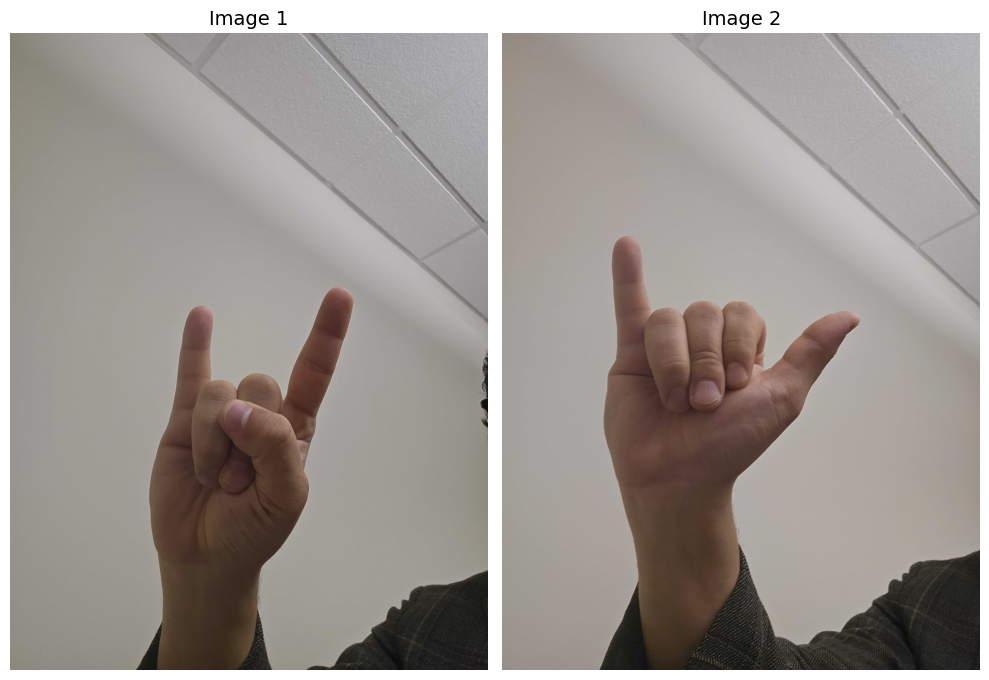

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, path, title in zip(axes, image_paths_ex, titles):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(title, fontsize=14)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:

# =========================
# STUDENT SECTION (EDIT THIS ONLY)
# =========================
prompt = """
Look at the image and determine whether the hand gesture corresponds to UT Austin or UT San Antonio.

You may briefly think about the gesture.

The final line must be exactly one of:
Class: UT Austin
Class: UT San Antonio
"""

demo1 = preprocess_image_to_data_url("./datasets/birds-vs-horns/horns-ex.jpg")
demo2 = preprocess_image_to_data_url("./datasets/birds-vs-horns/birds-ex.jpg")

# =========================
# RUN MODEL (DO NOT MODIFY)
# =========================
for i, path in enumerate(image_paths):
    img_url = preprocess_image_to_data_url(path)

    resp = client.chat.completions.create(
        model="qwen3-vl-32b-instruct",
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {"type": "image_url", "image_url": {"url": demo1}},
                ],
            },
            {
                "role": "assistant",
                "content": [{"type": "text", "text": "Class: UT Austin"}],
            },
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {"type": "image_url", "image_url": {"url": demo2}},
                ],
            },
            {
                "role": "assistant",
                "content": [{"type": "text", "text": "Class: UT San Antonio"}],
            },
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {"type": "image_url", "image_url": {"url": img_url}},
                ],
            }
        ],
        temperature=0.2,
        max_tokens=1000,
    )

    print(f"Image {i+1} Prediction:")
    print(resp.choices[0].message.content.strip())
    print("-" * 40)

Image 1 Prediction:
Class: UT Austin
----------------------------------------
Image 2 Prediction:
Class: UT Austin
----------------------------------------
Image 3 Prediction:
Class: UT Austin
----------------------------------------
Image 4 Prediction:
Class: UT San Antonio
----------------------------------------


## Key Idea

* Examples help the model learn the pattern
* Often improves formatting and accuracy



# Strategy 3: Chain-of-Thought Prompting

## What is Chain-of-Thought?

You encourage the model to **reason step-by-step** before answering.

Here, we explicitly allow reasoning, but enforce that the **final line is structured**.


## Example



In [16]:

# =========================
# STUDENT SECTION (EDIT THIS ONLY)
# =========================
prompt = """
Look at the hand gesture in the image.

First, describe what the gesture looks like.
Then determine whether it matches UT Austin or UT San Antonio.

After your reasoning, output the final answer.

The final line must be exactly one of:
Class: UT Austin
Class: UT San Antonio
"""

# =========================
# RUN MODEL (DO NOT MODIFY)
# =========================
for i, path in enumerate(image_paths):
    img_url = preprocess_image_to_data_url(path)

    resp = client.chat.completions.create(
        model="qwen3-vl-32b-instruct",
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {"type": "image_url", "image_url": {"url": img_url}},
                ],
            }
        ],
        temperature=0.2,
        max_tokens=1000,
    )

    print(f"Image {i+1} Prediction:")
    print(resp.choices[0].message.content.strip())
    print("-" * 40)

Image 1 Prediction:
The hand gesture shown in the image is the "hook 'em horns" gesture, commonly associated with the University of Texas at Austin. It is formed by extending the index and pinky fingers while curling the middle and ring fingers down toward the palm, with the thumb resting across them. This gesture is a well-known symbol of UT Austin, often used by fans, students, and alumni to show school spirit.

The gesture is not associated with UT San Antonio, which does not have this as its official hand signal. UT San Antonio’s mascot is the Roadrunners, and their primary symbols and gestures are different.

Therefore, based on the visual representation and cultural association, the gesture matches UT Austin.

Class: UT Austin
----------------------------------------
Image 2 Prediction:
The image displays a hand gesture commonly known as the "hook 'em horns" gesture, which is associated with the University of Texas at Austin (UT Austin). The gesture involves extending the index a

## Key Idea

* Encourages careful reasoning
* Helps with subtle visual differences
* Requires strict formatting control


# Strategy 4: Combination Prompting

## What is Combination?

You combine:

* examples (few-shot)
* reasoning (chain-of-thought)
* strict formatting

## Example

In [17]:

# =========================
# STUDENT SECTION (EDIT THIS ONLY)
# =========================
prompt = """
Look at the hand gesture in the image.

First, describe the gesture and what it represents.
Then determine whether it corresponds to UT Austin or UT San Antonio.

After reasoning, output the final answer.

The final line must be exactly one of:
Class: UT Austin
Class: UT San Antonio
"""

demo1 = preprocess_image_to_data_url("./datasets/birds-vs-horns/horns-ex.jpg")
demo2 = preprocess_image_to_data_url("./datasets/birds-vs-horns/birds-ex.jpg")

# =========================
# RUN MODEL (DO NOT MODIFY)
# =========================
for i, path in enumerate(image_paths):
    img_url = preprocess_image_to_data_url(path)

    resp = client.chat.completions.create(
        model="qwen3-vl-32b-instruct",
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {"type": "image_url", "image_url": {"url": demo1}},
                ],
            },
            {
                "role": "assistant",
                "content": [{"type": "text", "text": "Class: UT Austin"}],
            },
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {"type": "image_url", "image_url": {"url": demo2}},
                ],
            },
            {
                "role": "assistant",
                "content": [{"type": "text", "text": "Class: UT San Antonio"}],
            },
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {"type": "image_url", "image_url": {"url": img_url}},
                ],
            }
        ],
        temperature=0.2,
        max_tokens=1000,
    )

    print(f"Image {i+1} Prediction:")
    print(resp.choices[0].message.content.strip())
    print("-" * 40)


Image 1 Prediction:
The hand gesture shown is the "hook 'em horns" sign, formed by extending the index and pinky fingers while curling the middle and ring fingers down toward the palm, with the thumb holding them in place. This gesture is widely recognized as the official hand sign of the University of Texas at Austin (UT Austin). It is associated with the school's mascot, Bevo, and is used by students, alumni, and fans to show school spirit.

The gesture is not associated with UT San Antonio (UTSA), which uses a different hand sign — typically the "shaka" or "hang loose" gesture (thumb and pinky extended, other fingers curled) — to represent their "Roadrunners" mascot.

Therefore, this gesture corresponds to UT Austin.

Class: UT Austin
----------------------------------------
Image 2 Prediction:
The image displays a hand gesture commonly associated with university spirit, specifically the "hook 'em" gesture. The main image at the bottom shows a hand with the index finger and pinky ex

## Key Idea

* Combines strengths of all methods
* Often gives best performance
* Requires careful prompt design

# Final Takeaway

Even with the **same image**, results change depending on:

* how you structure the prompt
* whether you give examples
* whether you encourage reasoning

The most important control you have is:

> **What instructions you give before the model sees the image you care about**

## Final Exercise: Image Quality Classification (VizWiz)

### Scenario

You are building an AI system to help **people who are blind understand whether their photos are usable**.

Many real-world images suffer from quality issues. Your job is to design a prompt that helps the model correctly identify **what kind of issue is present**.


### Task

You will write a prompt for a vision-language model that classifies each image into **one of three categories**:

* `Class: Normal`
* `Class: Blur`
* `Class: Framing`

IMPORTANT: THE LAST LINE MUST BE `Class: CLASSNAMEHERE` any other format will result in an error or bad performance.


### Dataset (Simplified for Workshop)

You will evaluate your prompt on:

* **15 images total**
* You will also be given **3 example images** that you may use for few-shot prompting

Each image comes from a real dataset of photos taken by people who are blind, where:

* some images are clear (**Normal**)
* some are blurry (**Blur**)
* some are poorly framed (**Framing**)

### Goal

Maximize your **classification accuracy** across all 15 images.

This is a competition:

* highest accuracy wins



### Output Rules (Strict)

Your model output must follow this format:

* The **last line only** must be exactly one of:

  * `Class: Normal`
  * `Class: Blur`
  * `Class: Framing`

Additional rules:

* You may include reasoning before the final line
* The final line must match exactly (case and spacing matter)
* Do not include extra text after the final line
* Do not return multiple classes



### Understanding the Classes

Use these guidelines when designing your prompt:

* **Normal**

  * Image is clear and recognizable
  * Object is visible and centered
  * No major issues

* **Blur**

  * Image lacks sharpness
  * Objects appear smeared or out of focus
  * Details are hard to distinguish

* **Framing**

  * Object is cut off, partially missing, or poorly centered
  * Important parts are outside the image
  * Camera positioning is incorrect



### Strategy Tips

You may use any prompting strategy:

* Zero-shot (no examples)
* Few-shot (use the 3 example images)
* Chain-of-thought (reason before answering)
* Combination of all

Think about:

* what visual features define each class
* how to reduce confusion between blur vs framing
* how to enforce correct output formatting


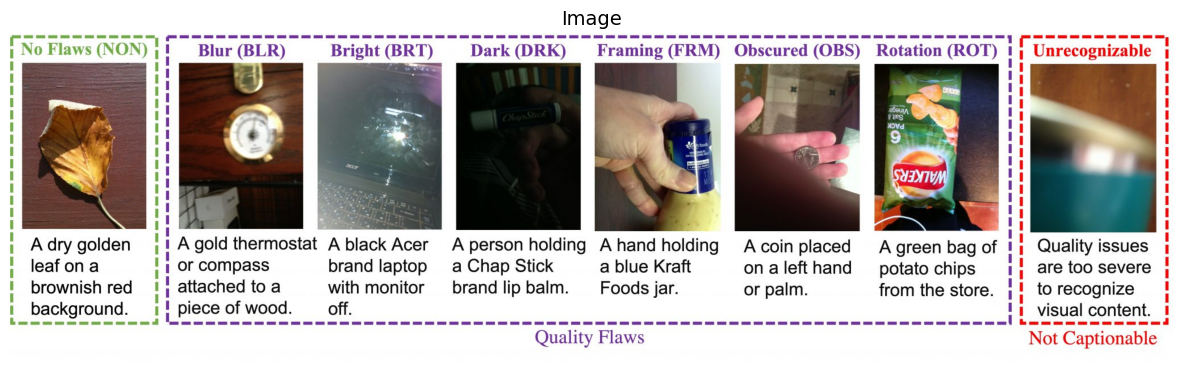

In [19]:
from PIL import Image
import matplotlib.pyplot as plt

# Load image
img = Image.open("./datasets/vizwiz.jpg")

# Display image
plt.figure(figsize=(15,15))
plt.imshow(img)
plt.axis("off")
plt.title("Image", fontsize=14)
plt.show()

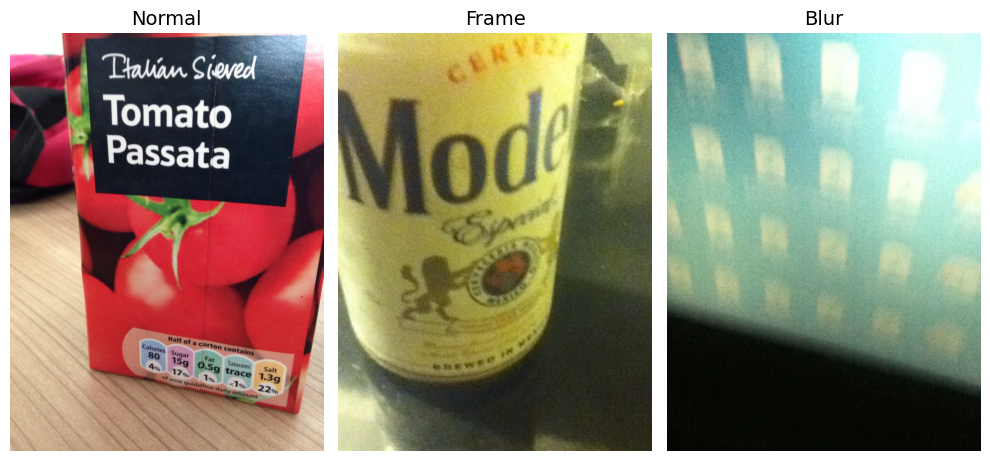

In [22]:

from utils import preprocess_image_to_data_url
from IPython.display import display, Markdown
from PIL import Image
import matplotlib.pyplot as plt

from openai import OpenAI

key = "gpustack_d230867d00abae37_390e4dac2dd24f61c4e2f6971c403883"
client = OpenAI(base_url="http://10.246.100.230/v1", api_key=key)

# Image paths
image_paths = [
    "./datasets/viz-wiz/ex_normal.jpg",
    "./datasets/viz-wiz/ex_frame.jpg",
    "./datasets/viz-wiz/ex_blur.jpg"
]

# Titles shown to students
titles = [
    "Normal",
    "Frame",
    "Blur",
]
fig, axes = plt.subplots(1, 3, figsize=(10, 10))
axes = axes.flatten()

for ax, path, title in zip(axes, image_paths, titles):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(title, fontsize=14)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [23]:
# =========================
# STUDENT SECTION (EDIT THIS ONLY)
# =========================
prompt = """
Look at the image and classify the image quality issue.

Possible classes:
Class: Normal
Class: Blur
Class: Framing

You may reason briefly if needed, but the last line must be exactly one of:
Class: Normal
Class: Blur
Class: Framing
"""

# =========================
# DO NOT EDIT
# =========================
import pandas as pd
from utils import preprocess_image_to_data_url

# Load csv with columns: image,label
df = pd.read_csv("./datasets/viz-wiz/annotations.csv")


predictions = []
correct = 0

for i, row in df.iterrows():
    image_path = f"./datasets/viz-wiz/{row['image']}"
    true_label = row["label"]

    img_url = preprocess_image_to_data_url(image_path)

    resp = client.chat.completions.create(
        model="qwen3-vl-32b-instruct",
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {"type": "image_url", "image_url": {"url": img_url}},
                ],
            }
        ],
        temperature=0.2,
        max_tokens=1000,
    )

    output = resp.choices[0].message.content.strip()
    last_line = output.split("\n")[-1].strip()

    # Assume last line is always: Class: classname
    pred_label = last_line.replace("Class:", "").strip()

    is_correct = pred_label == true_label
    correct += int(is_correct)

    predictions.append({
        "image": row["image"],
        "true_label": true_label,
        "pred_label": pred_label,
        "correct": is_correct,
        "full_output": output
    })

    print(f"{row['image']}")
    print(f"True: {true_label} | Pred: {pred_label} | Correct: {is_correct}")
    print("-" * 50)

accuracy = correct / len(df)

print(f"\nFinal Accuracy: {accuracy:.3f} ({correct}/{len(df)})")

VizWiz_val_00005141.jpg
True: Blur | Pred: Blur | Correct: True
--------------------------------------------------
VizWiz_val_00000516.jpg
True: Blur | Pred: Framing | Correct: False
--------------------------------------------------
VizWiz_val_00006140.jpg
True: Blur | Pred: Blur | Correct: True
--------------------------------------------------
VizWiz_val_00006553.jpg
True: Blur | Pred: Blur | Correct: True
--------------------------------------------------
VizWiz_val_00007686.jpg
True: Blur | Pred: Blur | Correct: True
--------------------------------------------------
VizWiz_val_00002854.jpg
True: Framing | Pred: Normal | Correct: False
--------------------------------------------------
VizWiz_val_00007258.jpg
True: Framing | Pred: Framing | Correct: True
--------------------------------------------------
VizWiz_val_00005789.jpg
True: Framing | Pred: Normal | Correct: False
--------------------------------------------------
VizWiz_val_00003112.jpg
True: Framing | Pred: Blur | Corre

### Think Before Running

Ask yourself:

* Does my prompt clearly define each class?
* Would a human follow these instructions correctly?
* Does my prompt reduce ambiguity between blur and framing?
* Will the model follow the output format exactly?